#PYTHON REPASO - LIBRERIAS - PANDAS - MATPLOTLIB - SEABORN

In [ ]:
import numpy as np #si pongo as np significa que lo voy a llamar np de acá en adelante para ahorrarme escritura
import matplotlib.pyplot as plt
import math
import pandas as pd
import seaborn as sns #libreria para hacer graficos estadísticos en python

#matplotlib https://matplotlib.org/

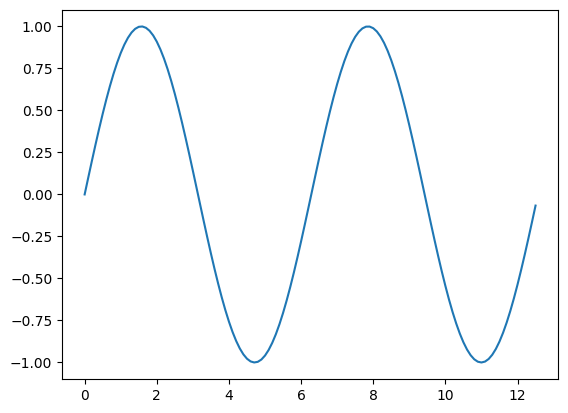

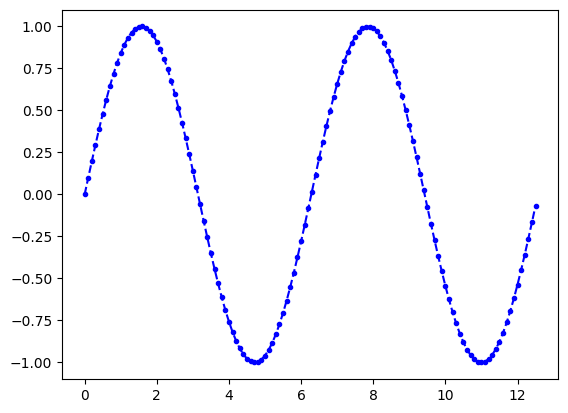

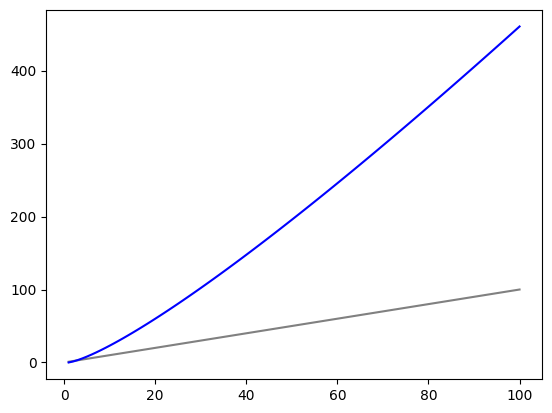

In [ ]:
#mapplotlit https://matplotlib.org/
x = np.arange(0, 4 * np.pi, 0.1)
y = np.sin(x)

plt.plot(x,y)
plt.show()

plt.plot(x,y,color='blue', marker='.', linestyle='dashed')
plt.show()


figura = plt.figure(dpi=100) #para que se vea más grande
x1 = np.array([p for p in range(1,101)])
y1 = x1.copy()
y2 = list(map(lambda x: x*math.log(x), x1))
plt.plot(x1,y1,color="gray",label="x")
plt.plot(x1,y2,color="blue", label="x * log(x)")
plt.show()





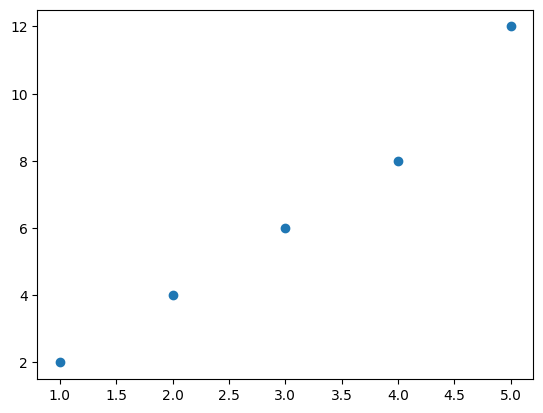

In [ ]:
#hay muchos tipos de figuras
figure = plt.figure(dpi=100) #dpi = 300 se ve re bien
x = [1,2,3,4,5]
y = [2,4,6,8,12]
plt.scatter(x,y) #scatter es una función que permite crear gráficos de dispersión

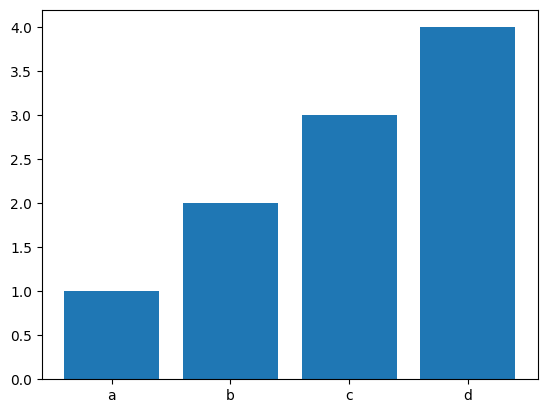

In [ ]:
#barras
figura = plt.figure(dpi=100)
plt.bar(height=[1,2,3,4],x=["a","b","c","d"])
plt.savefig('plot.png', dpi=300, bbox_inches='tight') #salvar la figura y busquen  en los archivos la carpetita

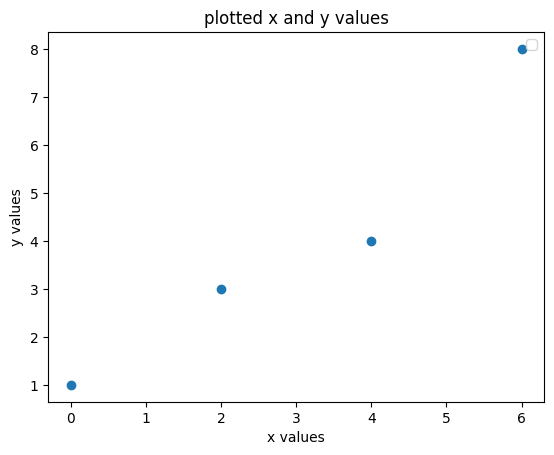

In [ ]:
x = [0, 2, 4, 6]
y = [1, 3, 4, 8]
plt.xlabel('x values')
plt.ylabel('y values')
plt.title('plotted x and y values')
plt.legend(['una linea'])
plt.scatter(x,y)
plt.show()

#Pandas : https://pandas.pydata.org/

In [ ]:
#creamos un objeto sencillo de pandas
s = pd.Series([1, 3, 5, np.nan, 6, 8]) #cuando lo creamos de esta manera directamente pandas pone un indice entero para cada elemento comenzando en 0
print(s)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64


In [ ]:
#También podemos crearnos una estructura de datos "Series" a partir de una lista o de un diccionario. Si la construimos a partir de una lista
#nos pondrá los índices por defecto y si lo creamos a partir de un diccionario, pondrá como índices las claves.
# Vamos a ver a continuación un ejemplo de como crear una Serie a partir de un diccionario y además vamos a ver como insertar en esta serie un nuevo elemento:

semana = {'lunes':'pilates', 'martes':'bicicleta', 'miércoles':'pilates', 'jueves':'bicicleta', 'viernes':'caminar', 8:'Cata colegio'}

actividades = pd.Series(semana)
print(actividades)



lunes             pilates
martes          bicicleta
miércoles         pilates
jueves          bicicleta
viernes           caminar
8            Cata colegio
dtype: object


In [ ]:
#DATA FRAME

dias = pd.date_range(start='25/04/2022', end='29/04/2022')
print(dias)

dias2= pd.date_range(start='25/04/2022', periods=5)
print(dias2)

#si observamos con atencion vamos a tener una matriz de 5 filas y 4 columnas donde la primer columna (los índices del dataframe) de nuestro dataframe estará formado por los días
#las columnas están nombradas según las letras A B C D
df = pd.DataFrame(np.random.randn(5, 4), index=dias, columns=list("ABCD"))
print(df)

DatetimeIndex(['2022-04-25', '2022-04-26', '2022-04-27', '2022-04-28',
               '2022-04-29'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2022-04-25', '2022-04-26', '2022-04-27', '2022-04-28',
               '2022-04-29'],
              dtype='datetime64[ns]', freq='D')
                   A         B         C         D
2022-04-25 -0.421973  0.392048  2.553949 -0.007851
2022-04-26 -2.816957  0.154946 -0.425356 -0.327818
2022-04-27 -0.662245 -0.249852 -0.385904  0.564362
2022-04-28  0.411586  0.364696  2.349598 -1.658679
2022-04-29  1.383841 -0.694075  0.117255  0.802576


#INTRO DE EDA (análisis exploratorio de datos) CON PYTHON

* DATASET iris:
El conjunto de datos Iris es un conjunto de medidas de flores de iris de tres especies. Es un ejemplo clásico de aprendizaje automático y análisis estadístico. Contiene 150 registros. Cada registro tiene 4 características predictivas: longitud y ancho de sépalos y pétalos. Las especies de flores son Iris setosa, Iris virginica e Iris versicolor. Este conjunto de datos o dataset es utilizado para construir un modelo que utilice las características de las flores para clasificarlas con un máximo de precisión.

In [ ]:
#vamos a cargar un dataframe desde github
!wget https://github.com/acolivera/RN_datasets/raw/main/iris/iris.csv


--2025-04-01 12:20:31--  https://github.com/acolivera/RN_datasets/raw/main/iris/iris.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/acolivera/RN_datasets/main/iris/iris.csv [following]
--2025-04-01 12:20:32--  https://raw.githubusercontent.com/acolivera/RN_datasets/main/iris/iris.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4026 (3.9K) [text/plain]
Saving to: ‘iris.csv.2’

iris.csv.2          100%[===================>]   3.93K  --.-KB/s    in 0s      

2025-04-01 12:20:32 (42.2 MB/s) - ‘iris.csv.2’ saved [4026/4026]



In [ ]:
dfiris = pd.read_csv('iris.csv')
#lo primero que tenemos que hacer es mirar los datos con los que vamos a trabajar
#vamos a tomar como ejemplo iris.csv que es una https://en.wikipedia.org/wiki/Iris_flower_data_set
print('los primeros 5 registros',dfiris.head())
print('los últimos 5 registros',dfiris.tail())

los primeros 5 registros    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
los últimos 5 registros      Sepal.Length  Sepal.Width  Petal.Length  Petal.Width    Species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [ ]:
dfiris.describe(include='all') # analytical summary of the dataset

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [ ]:
dfiris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


array([[<Axes: title={'center': 'Sepal.Length'}>,
        <Axes: title={'center': 'Sepal.Width'}>],
       [<Axes: title={'center': 'Petal.Length'}>,
        <Axes: title={'center': 'Petal.Width'}>]], dtype=object)

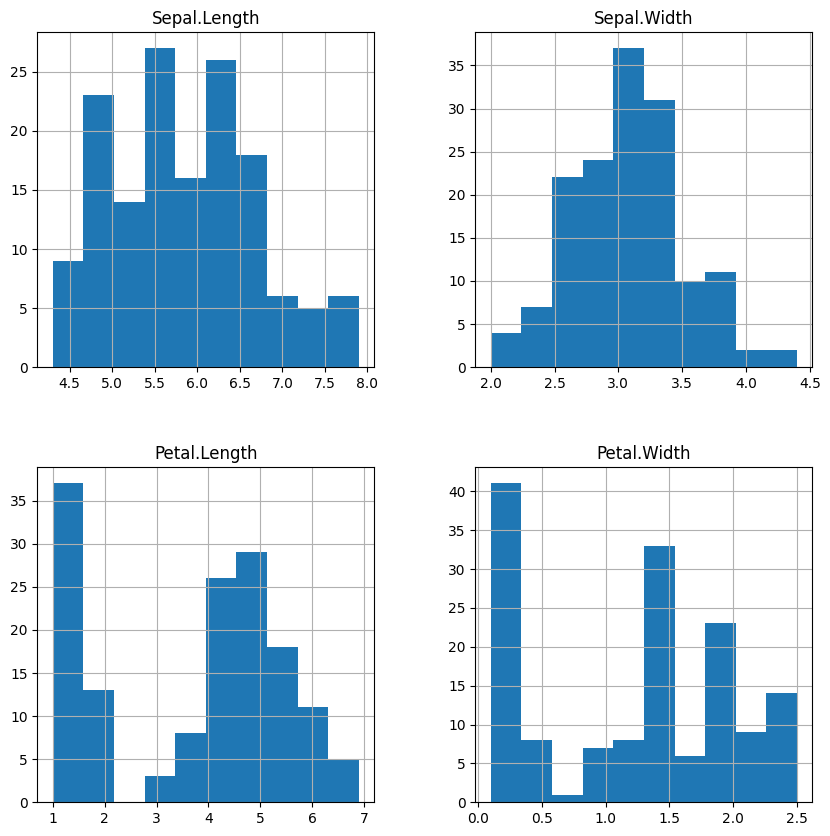

In [ ]:
dfiris.hist(figsize=(10,10)) # me resume la distribución de las variables relevantes

<Axes: xlabel='Species', ylabel='Petal.Length'>

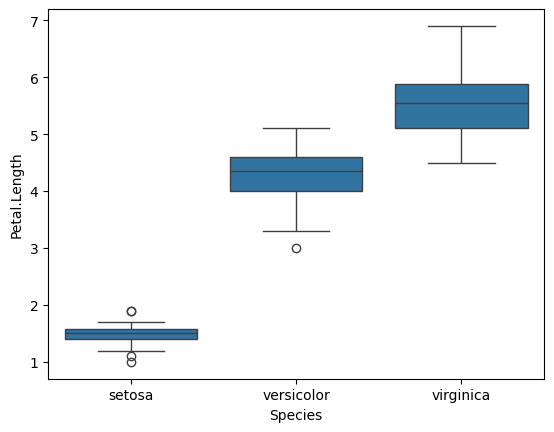

In [ ]:
sns.boxplot(x="Species", y="Petal.Length", data = dfiris)  # vemos si hay una relacion entre las especies y el tamaño de su petalo

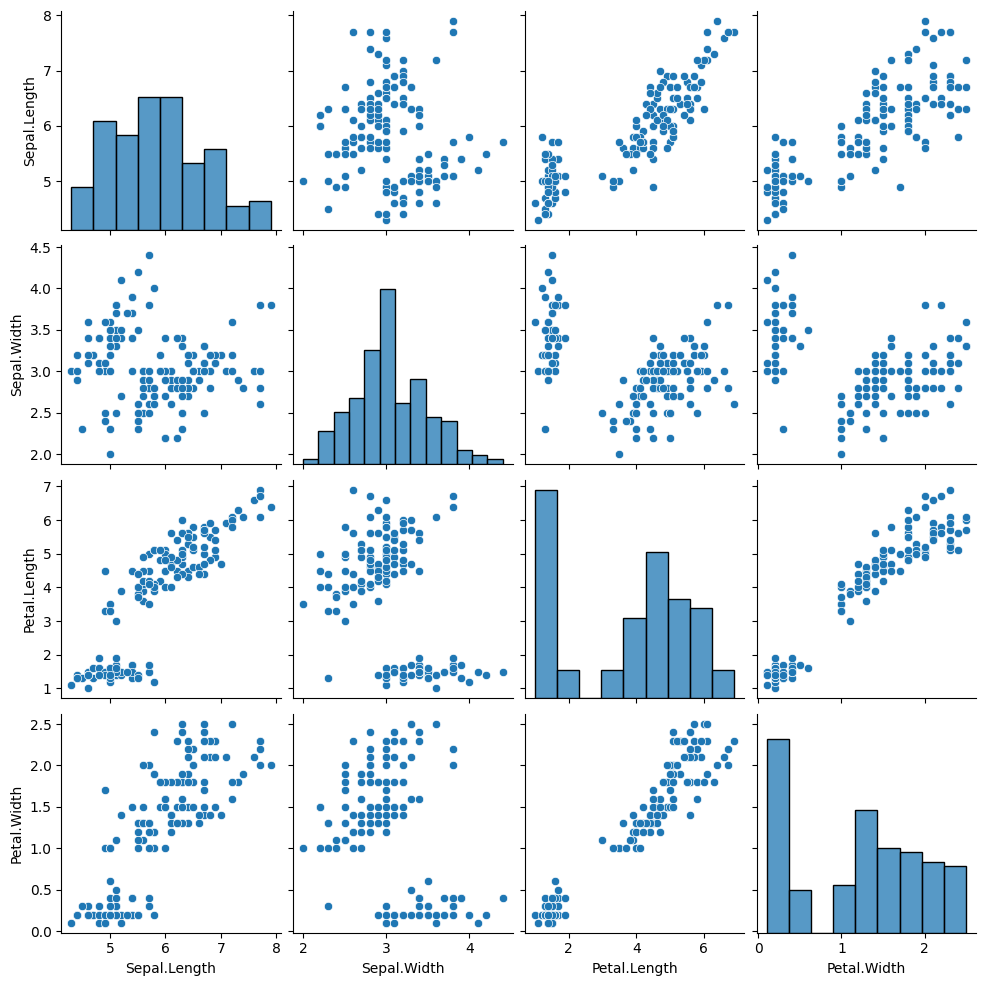

In [ ]:
sns.pairplot(dfiris)

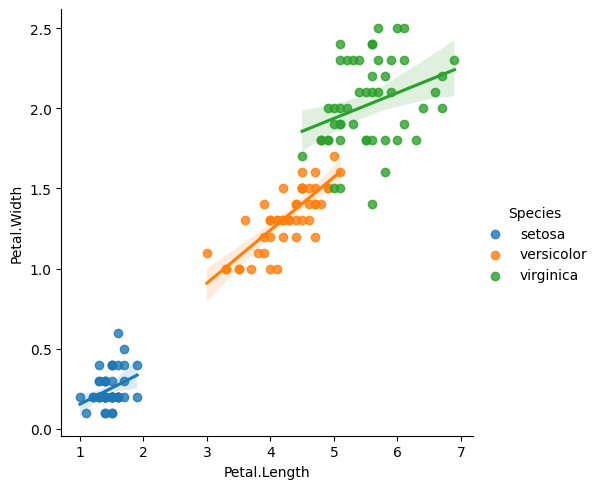

In [ ]:
#La función seaborn. lmplot() crea un diagrama de dispersión básico usando los datos dados en un FacetGrid y los combina con regplot.
sns.lmplot(x='Petal.Length', y ='Petal.Width', data= dfiris, hue='Species')

* DATAFRAME wine

In [ ]:
!wget https://github.com/acolivera/RN_datasets/raw/main/wine/wine.data
!wget https://github.com/acolivera/RN_datasets/raw/main/wine/wine.names

--2025-04-01 12:20:38--  https://github.com/acolivera/RN_datasets/raw/main/wine/wine.data
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/acolivera/RN_datasets/main/wine/wine.data [following]
--2025-04-01 12:20:38--  https://raw.githubusercontent.com/acolivera/RN_datasets/main/wine/wine.data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10782 (11K) [text/plain]
Saving to: ‘wine.data.1’

wine.data.1         100%[===================>]  10.53K  --.-KB/s    in 0s      

2025-04-01 12:20:38 (44.0 MB/s) - ‘wine.data.1’ saved [10782/10782]

--2025-04-01 12:20:38--  https://github.com/acolivera/RN_dat

In [ ]:
filewine = np.loadtxt('wine.data',delimiter=',') #loadtxt para levantar el archivo
filewine.view()

array([[1.000e+00, 1.423e+01, 1.710e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.000e+00, 1.320e+01, 1.780e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.000e+00, 1.316e+01, 2.360e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [3.000e+00, 1.327e+01, 4.280e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [3.000e+00, 1.317e+01, 2.590e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [3.000e+00, 1.413e+01, 4.100e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [ ]:
columnas = ["Class","Alcohol","Malic acid","Ash","Alcalinity of ash", "Magnesium", "Total phenols",
            "Flavanoids","Nonflavanoid phenols", "Proanthocyanins","Color intensity","Hue","OD280/OD315 of diluted wines","Proline"]
dfwine = pd.DataFrame(filewine, index=range(178), columns=columnas)
dfwine.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1.0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1.0,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1.0,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1.0,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1.0,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
dfwine.describe(include='all')

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
dfwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    float64
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    float64
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

array([[<Axes: title={'center': 'Class'}>,
        <Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'Malic acid'}>,
        <Axes: title={'center': 'Ash'}>],
       [<Axes: title={'center': 'Alcalinity of ash'}>,
        <Axes: title={'center': 'Magnesium'}>,
        <Axes: title={'center': 'Total phenols'}>,
        <Axes: title={'center': 'Flavanoids'}>],
       [<Axes: title={'center': 'Nonflavanoid phenols'}>,
        <Axes: title={'center': 'Proanthocyanins'}>,
        <Axes: title={'center': 'Color intensity'}>,
        <Axes: title={'center': 'Hue'}>],
       [<Axes: title={'center': 'OD280/OD315 of diluted wines'}>,
        <Axes: title={'center': 'Proline'}>, <Axes: >, <Axes: >]],
      dtype=object)

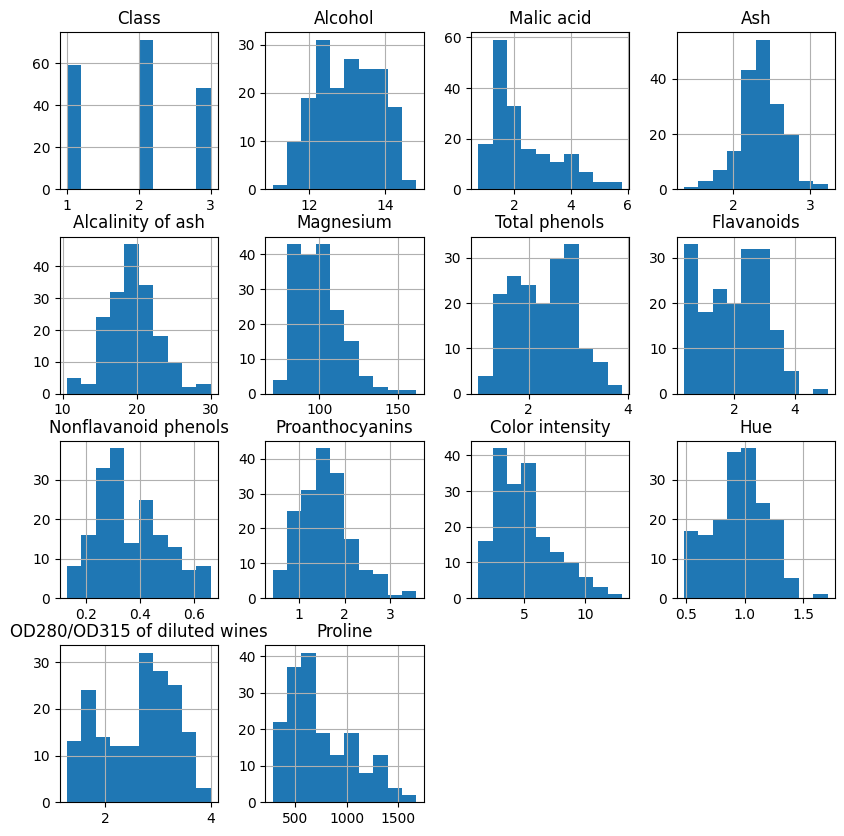

In [ ]:
dfwine.hist(figsize=(10,10))

<Axes: xlabel='Class', ylabel='Color intensity'>

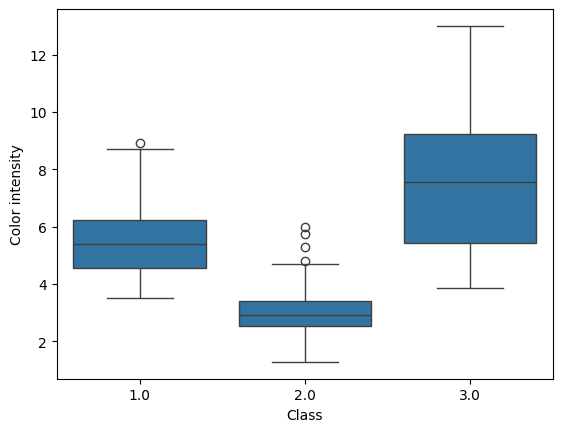

In [ ]:

sns.boxplot(x="Class", y="Color intensity", data = dfwine)

<Axes: xlabel='Species', ylabel='count'>

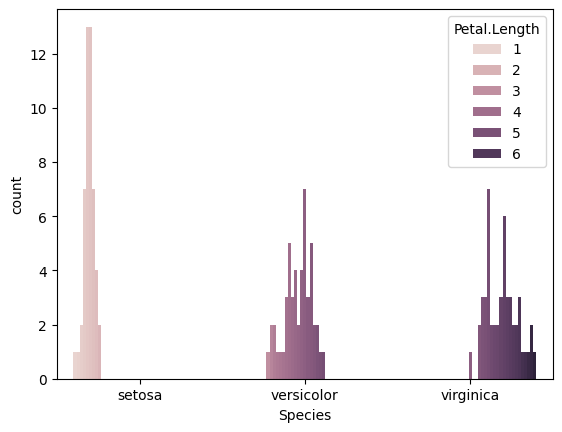

In [ ]:

sns.countplot(x="Species", hue = "Petal.Length", data = dfiris,orient='h')

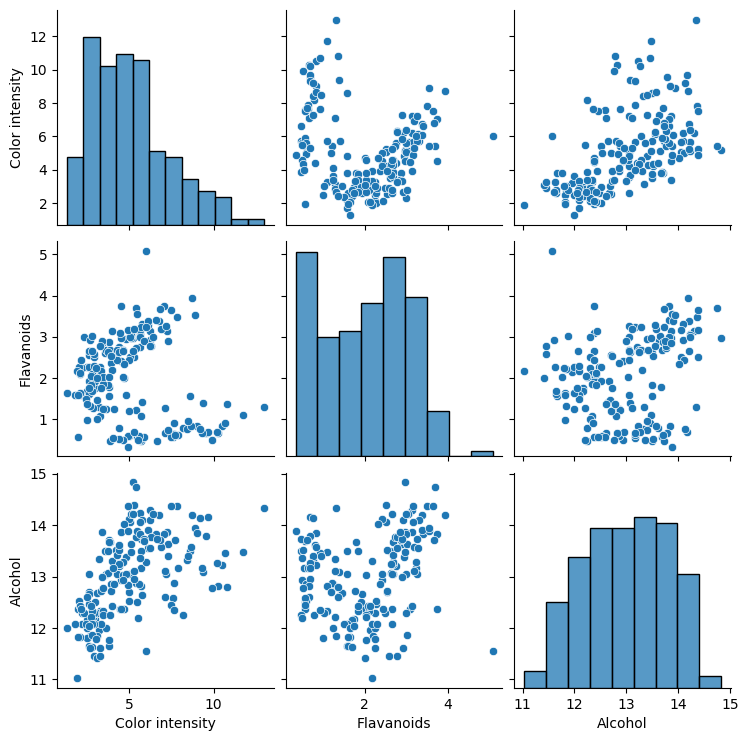

In [ ]:
sns.pairplot(dfwine, vars = ['Color intensity', 'Flavanoids','Alcohol'])

<ipython-input-57-d70755577f2d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dfwine['Class'])


<Axes: xlabel='Class', ylabel='Density'>

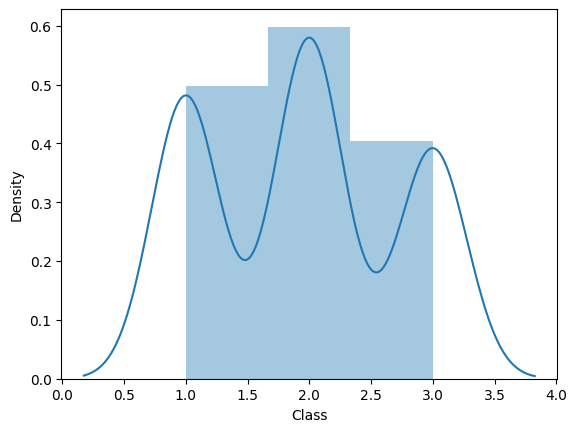

In [ ]:
sns.distplot(dfwine['Class'])

<Axes: >

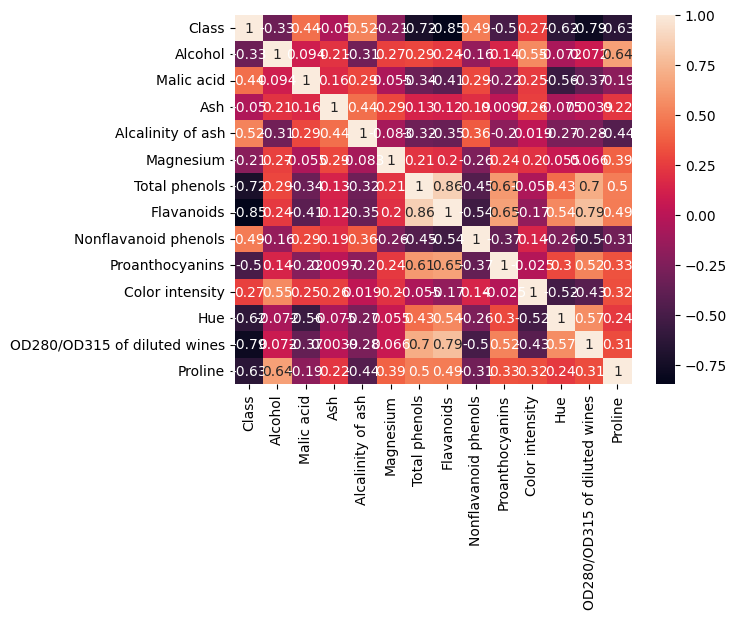

In [ ]:
corr= dfwine.corr() #usamos el de iris que se ve mejor
#correlacion Consiste en analizar la relación entre, al menos, dos variables -
#p.e. dos campos de una base de datos o de un log o raw data-. El resultado debe mostrar la fuerza y el sentido de la relación.
sns.heatmap(corr, annot=True)

In [ ]:
#Assigning a hue variable adds a semantic mapping and changes the default marginal plot to a layered kernel density estimate (KDE):
# sns.pairplot(dfwine[dfwine['Alcohol'] > 12], #tomo solo los que tienen mas de 12% de alcohol
#              vars = ['Total phenols', 'Color intensity', 'Flavanoids','Alcohol'], diag_kind = 'kde',
#              plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
#              height = 4,hue='Class');
#Assigning a hue variable adds a semantic mapping and changes the default marginal plot to a layered kernel density estimate (KDE):
#En Estadística, la estimación de densidad de Kernel (KDE) es una forma no paramétrica para estimar la función de densidad de probabilidad de una variable aleatoria.

sns.pairplot(dfwine, #KDE = kernel density estimation Calcula la estimación de la densidad del kernel (PDE) de los datos de la muestra.
             vars = ['Color intensity', 'Flavanoids','Alcohol'], diag_kind = 'kde',
             plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
             height = 4,hue='Class');


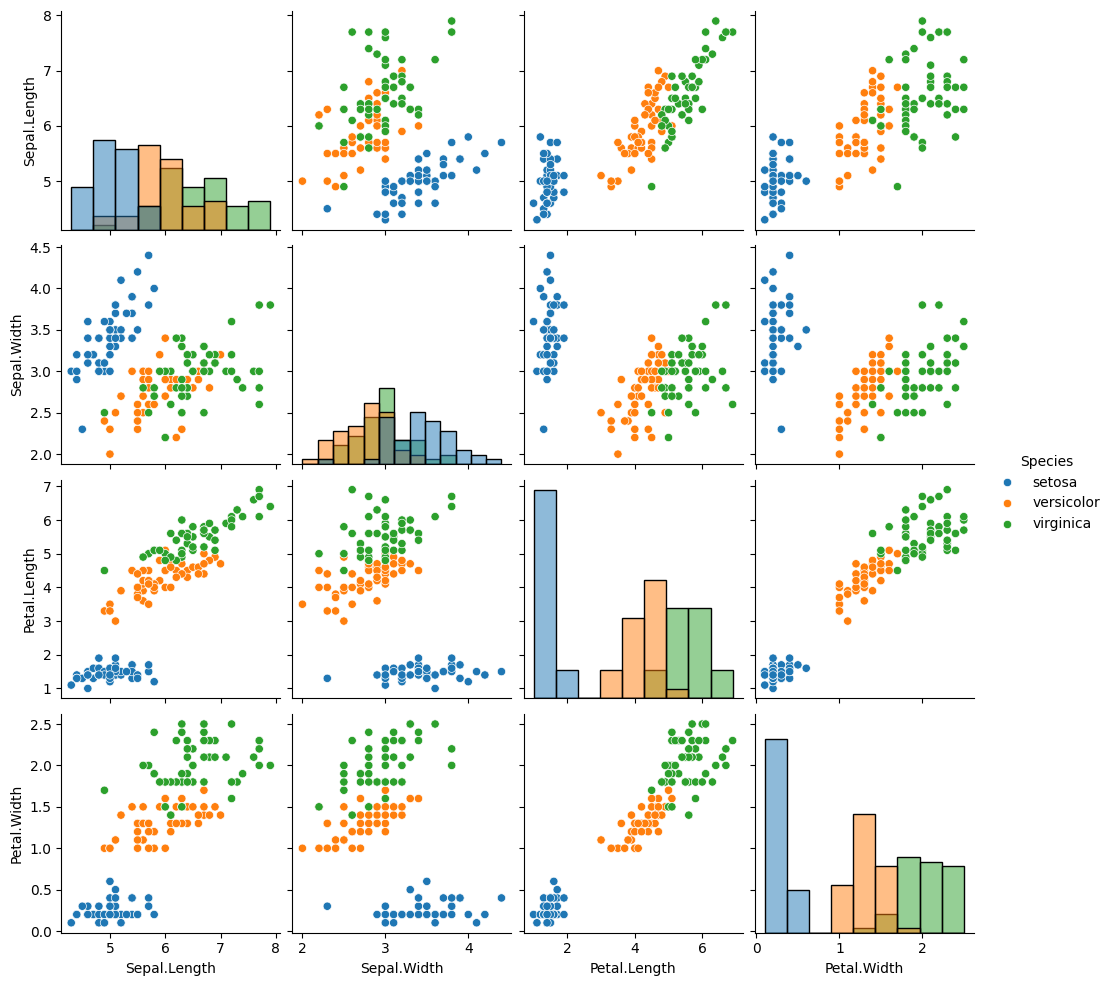

In [ ]:
#It’s possible to force marginal histograms: esto me ayuda a saber que variable es la que puede llegar a ayudarme a dividir los datos (clasificar) las clases
sns.pairplot(dfiris, hue="Species", diag_kind="hist")

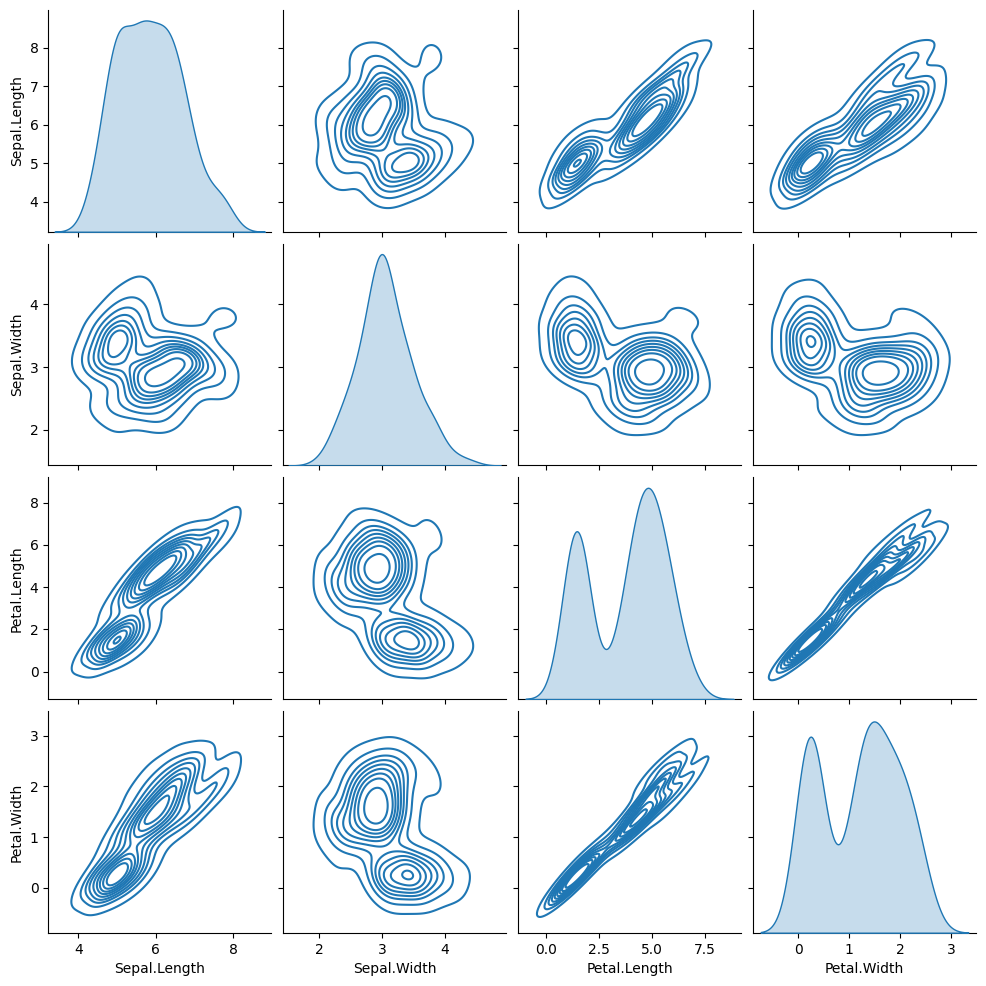

In [ ]:
sns.pairplot(dfiris, kind="kde")